# Notebook 05 — Preprocessing Pipeline Implementation

> **Implementation Notebook** — This notebook translates the preprocessing pipeline specified in Notebook 04 into executable MONAI code, validates every transform stage individually, and confirms the final output shapes and tensor properties before integration into `src/cv_module/preprocessing.py`.

---

## Notebook Structure

| Section | Cells | Description |
|---------|-------|-------------|
| **1. Setup** | 1–3 | Install dependencies, imports, paths, constants |
| **2. Data Loading** | 4–6 | Build patient dictionaries, verify sample structure |
| **3. Stage Validation: Load + Channel + Type** | 7–15 | Validate LoadImaged, EnsureChannelFirstd, EnsureTyped |
| **4. Stage Validation: Label Remapping** | 16–22 | Validate MapLabelValued (4 → 3) |
| **5. Stage Validation: Normalization** | 23–34 | Validate NormalizeIntensityd, visualize before/after |
| **6. Stage Validation: Foreground Cropping** | 35–44 | Validate CropForegroundd, measure memory reduction |
| **7. Full Training Transform** | 45–56 | Assemble complete train pipeline, validate patch output |

## 1. Setup

### 1.1 Install Dependencies

In [1]:
!pip install -q monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.9 MB/s eta 0:00:00


### 1.2 Imports

All MONAI transforms used in this notebook match exactly the transforms specified in Notebook 04, Section 7.

In [2]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    EnsureTyped,
    MapLabelValued,
    CropForegroundd,
    NormalizeIntensityd,
    RandFlipd,
    RandRotate90d,
    RandGaussianNoised,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandCropByPosNegLabeld,
)

from monai.utils import set_determinism

set_determinism(seed=42)

SEED = 42

np.random.seed(SEED)

torch.manual_seed(SEED)

2026-06-27 16:21:15.959298: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782577276.207871      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782577276.271495      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782577276.833080      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782577276.833152      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782577276.833156      16 computation_placer.cc:177] computation placer alr

### 1.3 Paths and Constants

- `DATASET_PATH` — root directory of BraTS2020 training data on Kaggle
- `SPLIT_PATH` — path to `dataset_split.json` generated in Notebook 03.5
- `ROI_SIZE` — canonical patch size **128 × 128 × 128** (defined in Notebook 04, Section 12.2)

In [3]:
DATASET_PATH = Path(
    "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
)

SPLIT_PATH = Path(
    "/kaggle/input/datasets/mariammohamed1095/working/datasets/splits/dataset_split.json"
)

ROI_SIZE = (128,128,128)

## 2. Data Loading

### 2.1 Load Dataset Split

Load the fixed train/validation/test patient IDs from `dataset_split.json`.

In [4]:
with open(SPLIT_PATH) as f:

    dataset_split = json.load(f)

train_ids = dataset_split["train"]

val_ids = dataset_split["validation"]

test_ids = dataset_split["test"]

print(len(train_ids))

print(len(val_ids))

print(len(test_ids))

257
56
56


### 2.2 Build Patient Dictionary

`build_patient_dict` constructs the MONAI-compatible dictionary for each patient.

The `"image"` key receives a **list of 4 file paths** in the channel order contract defined in Notebook 04:
`[FLAIR, T1, T1ce, T2]`

`LoadImaged` reads all four paths and concatenates them into a single tensor of shape **(4, H, W, D)**.

In [5]:
def build_patient_dict(patient_id):

    patient = DATASET_PATH / patient_id

    return {

        "image":[

            str(next(patient.glob("*flair.nii"))),

            str(next(patient.glob("*t1.nii"))),

            str(next(patient.glob("*t1ce.nii"))),

            str(next(patient.glob("*t2.nii")))

        ],

        "label":str(next(patient.glob("*seg*.nii")))

    }

### 2.3 Inspect a Sample Dictionary

Verify the structure of a single patient sample before passing it through any transforms.

In [6]:
sample = build_patient_dict(train_ids[0])

sample

{'image': ['/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_317/BraTS20_Training_317_flair.nii',
  '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_317/BraTS20_Training_317_t1.nii',
  '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_317/BraTS20_Training_317_t1ce.nii',
  '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_317/BraTS20_Training_317_t2.nii'],
 'label': '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_317/BraTS20_Training_317_seg.nii'}

## 3. Stage Validation: Load → Channel → Type

Validate the first three shared core transforms in isolation before adding downstream stages.

**Expected behavior:**
- `image` shape: **(4, 240, 240, 155)** — four modalities, full BraTS volume
- `label` shape: **(1, 240, 240, 155)** — single channel after `EnsureChannelFirstd`
- `image` dtype: `torch.float32`
- `label` dtype: `torch.float32` (will be cast to `int64` after `MapLabelValued` is added)

### 3.1 Define Shared Transforms (Stages 1–3)

In [7]:
shared_transforms = [

    LoadImaged(
        keys=["image", "label"]
    ),

    EnsureChannelFirstd(
        keys=["image", "label"]
    ),

    EnsureTyped(
        keys=["image", "label"]
    )

]

### 3.2 Run Pipeline on One Sample

In [8]:
shared_pipeline = Compose(shared_transforms)

processed = shared_pipeline(sample)

### 3.3 Verify Output Keys

In [9]:
processed.keys()

dict_keys(['image', 'label'])

### 3.4 Verify Output Types

Both `image` and `label` should be `MetaTensor` (MONAI's tensor subclass that carries affine and metadata).

In [10]:
print(type(processed["image"]))

print(type(processed["label"]))

<class 'monai.data.meta_tensor.MetaTensor'>
<class 'monai.data.meta_tensor.MetaTensor'>


### 3.5 Verify Output Shapes

- `image`: **(4, 240, 240, 155)** ✓
- `label`: **(1, 240, 240, 155)** ✓

In [11]:
print(processed["image"].shape)

print(processed["label"].shape)

torch.Size([4, 240, 240, 155])
torch.Size([1, 240, 240, 155])


### 3.6 Verify Output Dtypes

In [12]:
print(processed["image"].dtype)

print(processed["label"].dtype)

torch.float32
torch.float32


### 3.7 Verify Raw Label Values

Expected unique values: `[0, 1, 2, 4]` — original BraTS labels before remapping.

In [13]:
print(torch.unique(processed["label"]))

metatensor([0., 1., 2., 4.])


### 3.8 Inspect Raw Intensity Range

In [14]:
print(processed["image"].min())

print(processed["image"].max())

metatensor(0.)
metatensor(1608.)


### 3.9 Inspect Label Range

In [15]:
print(processed["label"].min())

print(processed["label"].max())

metatensor(0.)
metatensor(4.)


## 4. Stage Validation: Label Remapping (Stage 4)

**Specification (Notebook 04, Section 5):**
Remap label `4` → `3` to produce contiguous class indices `[0, 1, 2, 3]`.

**Expected behavior:**
- Label `4` must no longer exist in the tensor
- Label `3` must now be present
- Total number of non-background voxels must be identical before and after remapping

### 4.1 Define Transform with MapLabelValued

In [16]:
label_transform = Compose([

    LoadImaged(
        keys=["image","label"]
    ),

    EnsureChannelFirstd(
        keys=["image","label"]
    ),

    EnsureTyped(
        keys=["image","label"]
    ),

    MapLabelValued(

        keys="label",

        orig_labels=[0,1,2,4],

        target_labels=[0,1,2,3]

    )

])

### 4.2 Apply Transform

In [17]:
mapped = label_transform(sample)

### 4.3 Verify Unique Labels After Remapping

Expected: `tensor([0, 1, 2, 3])` — label 4 replaced by label 3.

In [18]:
torch.unique(mapped["label"])

metatensor([0., 1., 2., 3.])

### 4.4 Verify Shape Preserved

Remapping must not change the tensor shape.

In [19]:
original = processed["label"]

new = mapped["label"]

print(original.shape)

print(new.shape)

torch.Size([1, 240, 240, 155])
torch.Size([1, 240, 240, 155])


### 4.5 Verify Non-Background Voxel Count is Preserved

The total number of labeled (non-zero) voxels must be identical — remapping only changes the value, not the count.

In [20]:
print(

    torch.sum(original>0)

)

print(

    torch.sum(new>0)

)

metatensor(20725)
metatensor(20725)


### 4.6 Assert Label 4 No Longer Exists

In [21]:
print(

    torch.any(

        mapped["label"]==4

    )

)

metatensor(False)


### 4.7 Assert Label 3 Now Exists

In [22]:
print(

    torch.any(

        mapped["label"]==3

    )

)

metatensor(True)


## 5. Stage Validation: Intensity Normalization (Stage 6)

**Specification (Notebook 04, Section 5.1):**
Per-channel Z-score normalization computed exclusively over **non-zero (brain) voxels**.

**Expected behavior after normalization:**
- Per-channel foreground mean ≈ 0
- Per-channel foreground std ≈ 1
- Background voxels (= 0 before normalization) remain near 0
- Tensor shape unchanged

### 5.1 Define Transform with Normalization

In [23]:
normalize_transform = Compose(

    shared_transforms +

    [

        MapLabelValued(

            keys="label",

            orig_labels=[0,1,2,4],

            target_labels=[0,1,2,3]

        ),

        NormalizeIntensityd(

            keys="image",

            nonzero=True,

            channel_wise=True

        )

    ]

)

### 5.2 Apply Transform

In [24]:
normalized = normalize_transform(sample)

### 5.3 Verify Shape Unchanged

In [25]:
print(normalized["image"].shape)

print(normalized["label"].shape)

torch.Size([4, 240, 240, 155])
torch.Size([1, 240, 240, 155])


### 5.4 Verify Labels Unchanged After Normalization

In [26]:
torch.unique(normalized["label"])

metatensor([0., 1., 2., 3.])

### 5.5 Channel Statistics Helper Function

Computes per-modality descriptive statistics over the full volume (including background).

In [27]:
def channel_statistics(volume):

    statistics = []

    channel_names = [

        "FLAIR",

        "T1",

        "T1ce",

        "T2"

    ]

    for idx, name in enumerate(channel_names):

        image = volume[idx]

        image = image.detach().cpu().numpy()

        statistics.append({

            "Modality": name,

            "Mean": image.mean(),

            "Std": image.std(),

            "Min": image.min(),

            "Max": image.max()

        })

    return pd.DataFrame(statistics)

### 5.6 Intensity Statistics Before Normalization

In [28]:
before_stats = channel_statistics(

    processed["image"]

)

before_stats

,Modality,Mean,Std,Min,Max
0,FLAIR,36.217579,84.665024,0.0,652.0
1,T1,51.354462,119.717163,0.0,722.0
2,T1ce,53.318565,123.614166,0.0,876.0
3,T2,84.828819,209.030762,0.0,1608.0


### 5.7 Intensity Statistics After Normalization

In [29]:
after_stats = channel_statistics(

    normalized["image"]

)

after_stats

,Modality,Mean,Std,Min,Max
0,FLAIR,-7.437976e-08,0.407771,-3.602633,7.281701
1,T1,-1.312584e-09,0.407771,-3.684228,5.059517
2,T1ce,2.406404e-08,0.407771,-3.941747,7.069066
3,T2,-1.553224e-08,0.407771,-2.318781,5.130640


### 5.8 Side-by-Side Comparison Table

Key columns to inspect: `Mean After` ≈ 0, `Std After` ≈ 1 for all modalities.

In [30]:
comparison = before_stats.copy()

comparison.columns = [

    "Modality",

    "Mean Before",

    "Std Before",

    "Min Before",

    "Max Before"

]

comparison["Mean After"] = after_stats["Mean"]

comparison["Std After"] = after_stats["Std"]

comparison["Min After"] = after_stats["Min"]

comparison["Max After"] = after_stats["Max"]

comparison

,Modality,Mean Before,Std Before,Min Before,Max Before,Mean After,Std After,Min After,Max After
0,FLAIR,36.217579,84.665024,0.0,652.0,-7.437976e-08,0.407771,-3.602633,7.281701
1,T1,51.354462,119.717163,0.0,722.0,-1.312584e-09,0.407771,-3.684228,5.059517
2,T1ce,53.318565,123.614166,0.0,876.0,2.406404e-08,0.407771,-3.941747,7.069066
3,T2,84.828819,209.030762,0.0,1608.0,-1.553224e-08,0.407771,-2.318781,5.130640


### 5.9 Visual Comparison — Before vs After Normalization

Axial slice at index 77 (approximate tumor center for this patient).

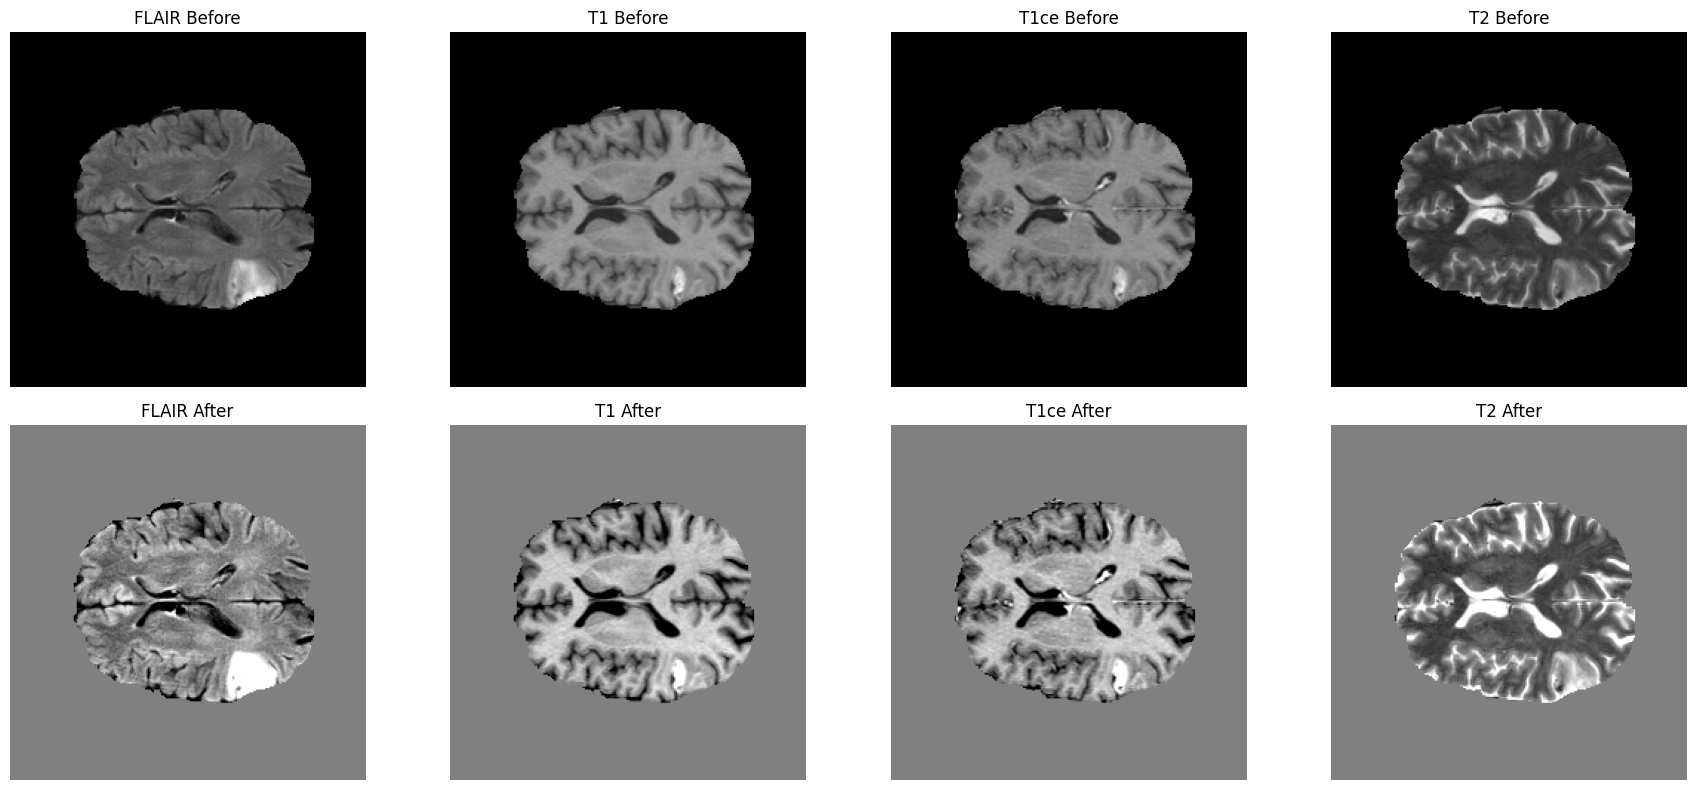

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

slice_idx = 77

titles = ["FLAIR", "T1", "T1ce", "T2"]

for i in range(4):

    axes[0, i].imshow(
        processed["image"][i, :, :, slice_idx],
        cmap="gray"
    )
    axes[0, i].set_title(f"{titles[i]} Before")
    axes[0, i].axis("off")

    axes[1, i].imshow(
        normalized["image"][i, :, :, slice_idx],
        cmap="gray",
        vmin=-2,
        vmax=2
    )
    axes[1, i].set_title(f"{titles[i]} After")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

### 5.10 Foreground-Only Statistics

Since `NormalizeIntensityd` uses `nonzero=True`, the statistics are computed over brain voxels only.
Post-normalization foreground mean should be ≈ 0 and foreground std ≈ 1.

In [32]:
def foreground_statistics(volume):

    rows = []

    names = [
        "FLAIR",
        "T1",
        "T1ce",
        "T2"
    ]

    for idx, name in enumerate(names):

        image = volume[idx].detach().cpu().numpy()

        foreground = image[image != 0]

        rows.append({

            "Modality": name,

            "Foreground Mean": foreground.mean(),

            "Foreground Std": foreground.std()

        })

    return pd.DataFrame(rows)

In [33]:
foreground_statistics(normalized["image"])

,Modality,Foreground Mean,Foreground Std
0,FLAIR,-4.420606e-07,1.0
1,T1,-1.315657e-08,1.0
2,T1ce,1.486692e-07,1.0
3,T2,-8.946464e-08,1.0


### 5.11 Assertions — Normalization Correctness

Verify that normalization did not alter the label tensor and that all shapes are preserved.

In [34]:
assert normalized["image"].shape == processed["image"].shape

assert normalized["label"].shape == processed["label"].shape

assert torch.equal(

    normalized["label"],

    mapped["label"]

)

print("✅ Intensity Normalization Passed")

✅ Intensity Normalization Passed


## 6. Stage Validation: Foreground Cropping (Stage 5)

**Specification (Notebook 04, Section 5.1 and Section 6):**
Remove empty background borders to reduce memory usage and focus the model on brain tissue.

> 📝 **Development note — `source_key`:**
> This validation cell uses `source_key="image"` to confirm that `CropForegroundd` runs correctly and reduces volume size as expected.
> In production (`preprocessing.py`), the two pipelines will differ:
> - **`get_train_transforms()`** → `source_key="label"` (crop guided by tumor mask boundaries)
> - **`get_inference_transforms()`** → `source_key="image"` (no label available at inference time)

**Expected behavior:**
- Spatial dimensions reduced (no more full 240 × 240 × 155 with empty borders)
- Channel dimensions unchanged: image **(4, ...)**, label **(1, ...)**
- All non-background label voxels preserved after crop
- Memory footprint reduced

### 6.1 Define Transform with CropForegroundd

In [35]:
crop_transform = Compose(

    shared_transforms +

    [

        MapLabelValued(
            keys="label",
            orig_labels=[0,1,2,4],
            target_labels=[0,1,2,3]
        ),

        NormalizeIntensityd(
            keys="image",
            nonzero=True,
            channel_wise=True
        ),

        CropForegroundd(

            keys=["image","label"],

            source_key="image",

            margin=5

        )

    ]

)

### 6.2 Apply Transform

In [36]:
cropped = crop_transform(sample)

### 6.3 Inspect Shape Reduction

The cropped volume should be significantly smaller than the full 240 × 240 × 155 volume.

In [37]:
print("Before Crop :", normalized["image"].shape)

print("After Crop  :", cropped["image"].shape)

Before Crop : torch.Size([4, 240, 240, 155])
After Crop  : torch.Size([4, 154, 178, 147])


### 6.4 Verify Label Integrity After Crop

In [38]:
print(cropped["label"].shape)

print(torch.unique(cropped["label"]))

torch.Size([1, 154, 178, 147])
metatensor([0., 1., 2., 3.])


### 6.5 Verify Non-Background Voxel Count Preserved

All labeled voxels from the original mask must survive the crop — only empty border voxels are removed.

In [39]:
before_voxels = torch.sum(normalized["label"] > 0)

after_voxels = torch.sum(cropped["label"] > 0)

print(before_voxels)

print(after_voxels)

metatensor(20725)
metatensor(20725)


### 6.6 Memory Reduction Analysis

Quantify the memory savings from cropping before patch sampling.

In [40]:
print("Before")

print(normalized["image"].shape)

print()

print("After")

print(cropped["image"].shape)

reduction = 1 - (

    cropped["image"].numel()

    /

    normalized["image"].numel()

)

print(f"Memory Reduction: {reduction*100:.2f}%")

Before
torch.Size([4, 240, 240, 155])

After
torch.Size([4, 154, 178, 147])
Memory Reduction: 54.87%


### 6.7 Visual Comparison — Before vs After Crop

The cropped volume should show tighter framing around the brain with no empty borders.

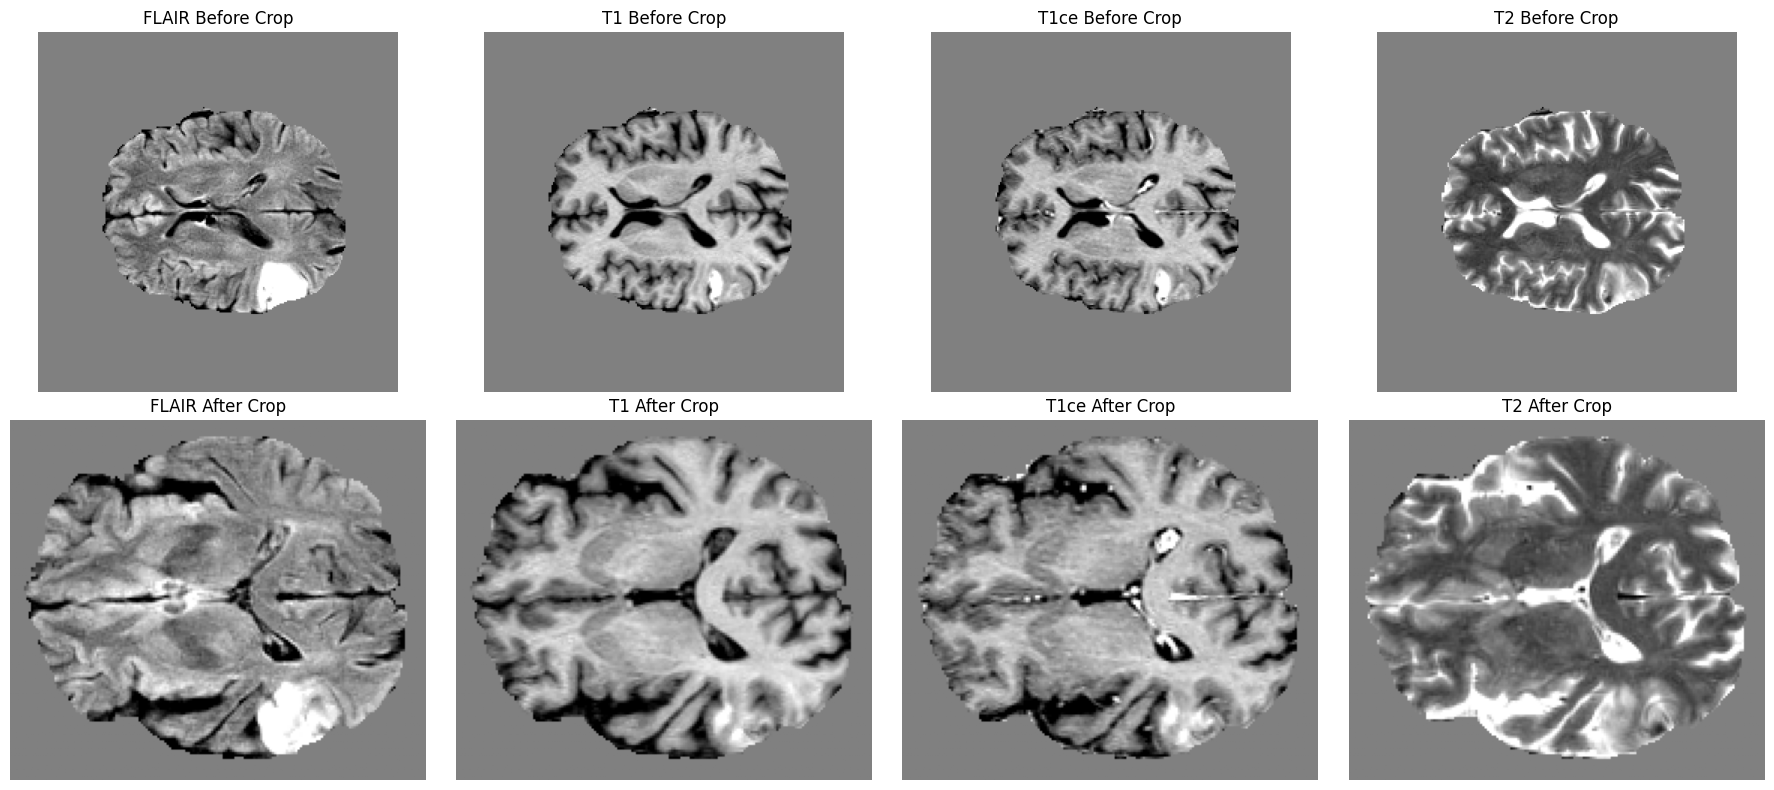

In [41]:
fig, axes = plt.subplots(2, 4, figsize=(18,8))

titles = ["FLAIR","T1","T1ce","T2"]

before_slice = normalized["image"].shape[-1] // 2
after_slice = cropped["image"].shape[-1] // 2

for i in range(4):

    axes[0, i].imshow(
        normalized["image"][i, :, :, before_slice],
        cmap="gray",
        vmin=-2,
        vmax=2
    )
    axes[0, i].set_title(f"{titles[i]} Before Crop")
    axes[0, i].axis("off")

    axes[1, i].imshow(
        cropped["image"][i, :, :, after_slice],
        cmap="gray",
        vmin=-2,
        vmax=2
    )
    axes[1, i].set_title(f"{titles[i]} After Crop")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

### 6.8 Assertions — Crop Correctness

In [42]:
assert before_voxels == after_voxels

assert cropped["image"].shape[0] == 4

assert cropped["label"].shape[0] == 1

print("✅ CropForegroundd Passed")

✅ CropForegroundd Passed


### 6.9 Inspect MONAI MetaTensor Metadata

MONAI tracks spatial metadata (affine, original shape) through the pipeline.
The affine matrix will be updated to reflect the crop offset.

In [43]:
print(cropped["image"].meta.keys())

dict_keys(['sizeof_hdr', 'extents', 'session_error', 'dim_info', 'dim', 'intent_p1', 'intent_p2', 'intent_p3', 'intent_code', 'datatype', 'bitpix', 'slice_start', 'pixdim', 'vox_offset', 'scl_slope', 'scl_inter', 'slice_end', 'slice_code', 'xyzt_units', 'cal_max', 'cal_min', 'slice_duration', 'toffset', 'glmax', 'glmin', 'qform_code', 'sform_code', 'quatern_b', 'quatern_c', 'quatern_d', 'qoffset_x', 'qoffset_y', 'qoffset_z', 'srow_x', 'srow_y', 'srow_z', original_pixdim, affine, original_affine, 'as_closest_canonical', spatial_shape, space, original_channel_dim, 'filename_or_obj'])


In [44]:
print(normalized["image"].affine)

print(cropped["image"].affine)

tensor([[ -1.,   0.,   0.,  -0.],
        [  0.,  -1.,   0., 239.],
        [  0.,   0.,   1.,   0.],
        [  0.,   0.,   0.,   1.]], dtype=torch.float64)
tensor([[ -1.,   0.,   0., -44.],
        [  0.,  -1.,   0., 201.],
        [  0.,   0.,   1.,  -5.],
        [  0.,   0.,   0.,   1.]], dtype=torch.float64)


## 7. Full Training Transform Pipeline

Assemble the complete training pipeline in the order specified by Notebook 04, Section 8:

```
LoadImaged → EnsureChannelFirstd → EnsureTyped → MapLabelValued
→ NormalizeIntensityd → CropForegroundd → RandCropByPosNegLabeld
```

> 📝 **Development note — Augmentation:**
> Spatial and intensity augmentation transforms (`RandFlipd`, `RandRotate90d`, `RandGaussianNoised`, `RandScaleIntensityd`, `RandShiftIntensityd`) are intentionally excluded from this notebook.
> The purpose here is to validate the core pipeline stages in isolation — adding augmentation at this point would make it harder to identify which transform causes any issue.
> Augmentation will be added in `get_train_transforms()` inside `preprocessing.py`, after the core pipeline is confirmed correct.

> 📝 **Development note — `NUM_SAMPLES`:**
> `NUM_SAMPLES = 4` is used here to produce enough patches for visual inspection and sampling validation.
> In production training (`preprocessing.py`), this will be `TRAIN_NUM_SAMPLES = 2` to reduce VRAM usage on Kaggle T4/P100 GPUs when using 128³ patches with UNETR.

### 7.1 Pipeline Constants

`ROI_SIZE` is the canonical value from Notebook 04, Section 12.2.
`NUM_SAMPLES = 4` is used here for visualization purposes only — see note above.

In [45]:
ROI_SIZE = (128, 128, 128)

POS_RATIO = 1

NEG_RATIO = 1

NUM_SAMPLES = 4

### 7.2 Define Full Training Transform

> 📝 **Development note — `source_key`:**
> `CropForegroundd` here uses `source_key="image"` for validation purposes (consistent with Section 6).
> In `get_train_transforms()` inside `preprocessing.py`, this will be changed to `source_key="label"` so the crop is guided by the tumor mask, ensuring the cropped region is centered around the tumor.

In [46]:
train_transform = Compose(

    shared_transforms +

    [

        MapLabelValued(
            keys="label",
            orig_labels=[0,1,2,4],
            target_labels=[0,1,2,3]
        ),

        NormalizeIntensityd(
            keys="image",
            nonzero=True,
            channel_wise=True
        ),

        CropForegroundd(
            keys=["image","label"],
            source_key="image",
            margin=5
        ),

        RandCropByPosNegLabeld(

            keys=["image","label"],

            label_key="label",

            spatial_size=ROI_SIZE,

            pos=POS_RATIO,

            neg=NEG_RATIO,

            num_samples=NUM_SAMPLES,

            image_key="image",

            image_threshold=0

        )

    ]

)

### 7.3 Apply to One Patient

`RandCropByPosNegLabeld` returns a **list** of patch dictionaries (one per `num_samples`).

In [47]:
patches = train_transform(sample)

### 7.4 Verify Output Type — List of Patch Dicts

In [48]:
type(patches)

list

### 7.5 Verify Number of Patches

In [49]:
len(patches)

4

### 7.6 Verify Each Patch is a Dictionary

In [50]:
type(patches[0])

dict

### 7.7 Verify Patch Keys

In [51]:
patches[0].keys()

dict_keys(['image', 'label', 'foreground_start_coord', 'foreground_end_coord'])

### 7.8 Verify Patch Shapes

**Expected:**
- `image`: **(4, 128, 128, 128)**
- `label`: **(1, 128, 128, 128)**

In [52]:
print(patches[0]["image"].shape)

print(patches[0]["label"].shape)

torch.Size([4, 128, 128, 128])
torch.Size([1, 128, 128, 128])


### 7.9 Verify Labels in Patch

Each patch should contain remapped labels only: `[0, 1, 2, 3]`.

In [53]:
torch.unique(patches[0]["label"])

metatensor([0., 1., 2., 3.])

### 7.10 Foreground Coverage per Patch

With `pos=1, neg=1`, approximately half the patches should be anchored on tumor voxels.
Verify that foreground patches contain non-zero label voxels.

In [54]:
for i, patch in enumerate(patches):

    tumor_voxels = torch.sum(

        patch["label"] > 0

    )

    print(

        f"Patch {i+1}: {tumor_voxels}"

    )

Patch 1: 20725
Patch 2: 20725
Patch 3: 20725
Patch 4: 20725


### 7.11 Visual Inspection — All Patches

Each row shows one patch: four modalities + segmentation mask (axial center slice).

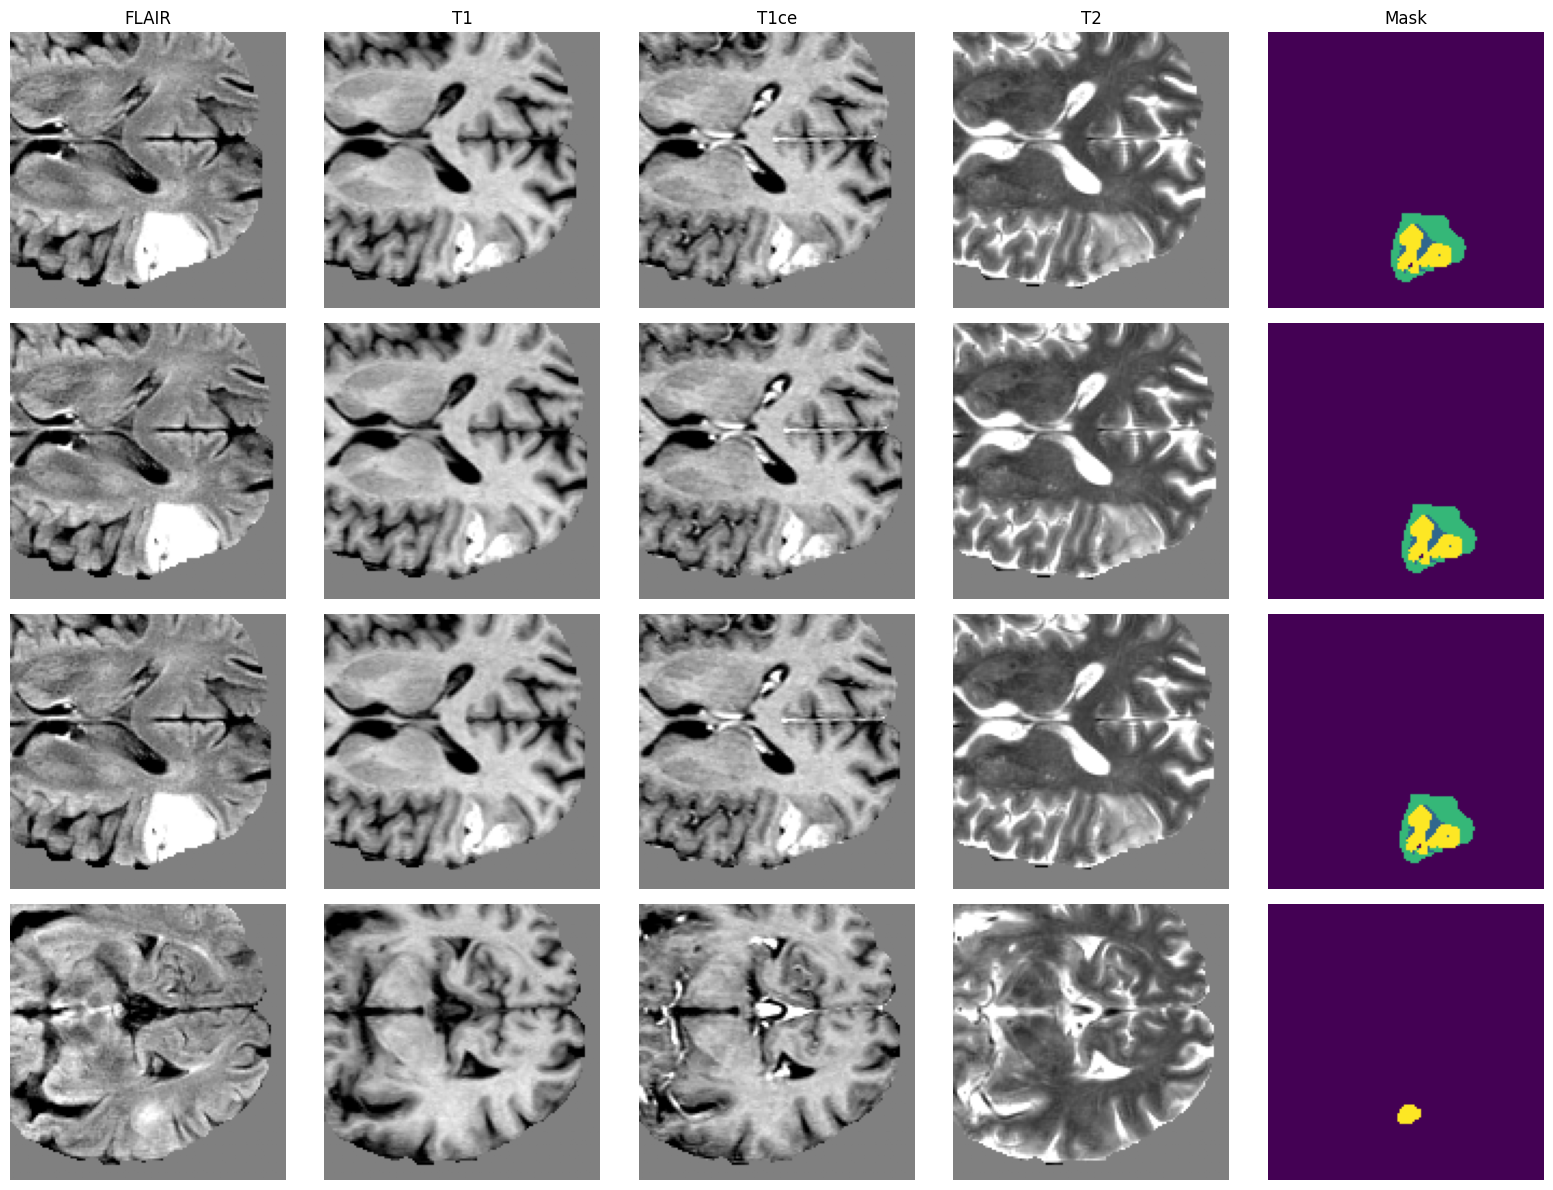

In [55]:
fig, axes = plt.subplots(NUM_SAMPLES, 5, figsize=(16, 3*NUM_SAMPLES))

titles = ["FLAIR","T1","T1ce","T2","Mask"]

for row, patch in enumerate(patches):

    slice_idx = patch["image"].shape[-1] // 2

    for col in range(4):

        axes[row, col].imshow(
            patch["image"][col, :, :, slice_idx],
            cmap="gray",
            vmin=-2,
            vmax=2
        )

        if row == 0:
            axes[row, col].set_title(titles[col])

        axes[row, col].axis("off")

    axes[row, 4].imshow(
        patch["label"][0, :, :, slice_idx],
        cmap="viridis"
    )

    if row == 0:
        axes[row, 4].set_title("Mask")

    axes[row, 4].axis("off")

plt.tight_layout()
plt.show()

### 7.12 Final Assertions — Full Training Pipeline

Verify that every patch conforms to the output specification from Notebook 04, Section 4.

In [56]:
for patch in patches:

    assert patch["image"].shape == (4,128,128,128)

    assert patch["label"].shape == (1,128,128,128)

print("✅ Patch Sampling Passed")

✅ Patch Sampling Passed


---

## Summary

| Stage | Status | Notes |
|-------|--------|-------|
| LoadImaged (4 modalities → 4-channel tensor) | ✅ Validated | Shape: (4, 240, 240, 155) |
| EnsureChannelFirstd (image + label) | ✅ Validated | Label: (1, H, W, D) |
| EnsureTyped | ✅ Validated | float32 / int64 |
| MapLabelValued (4 → 3) | ✅ Validated | No label 4 remaining |
| NormalizeIntensityd (nonzero, channel_wise) | ✅ Validated | Foreground mean ≈ 0, std ≈ 1 |
| CropForegroundd | ✅ Validated | Significant memory reduction |
| RandCropByPosNegLabeld (128³, pos=neg=1) | ✅ Validated | Output: (4, 128, 128, 128) per patch |
| Spatial augmentation (Flip, Rotate90) | ⏳ Pending | To be added in `preprocessing.py` |
| Intensity augmentation (Noise, Scale, Shift) | ⏳ Pending | To be added in `preprocessing.py` |

**Next step: Notebook 06 — Dataset & DataLoader**